#### 챔피언별 승률 기준으로 이상치 찾기
- Isolation Forest

In [1]:
# 데이터 호출
import pandas as pd

df_champion = pd.read_csv('../../유저단위_게임데이터_상위랭커보존-stats_champion_1.csv')


In [2]:
print(df_champion.info())

display(df_champion.head(1))

<class 'pandas.DataFrame'>
RangeIndex: 396204 entries, 0 to 396203
Data columns (total 10 columns):
 #   Column            Non-Null Count   Dtype
---  ------            --------------   -----
 0   user_id           396204 non-null  str  
 1   game_id           396204 non-null  str  
 2   user_tier         396204 non-null  str  
 3   ranked            396204 non-null  int64
 4   flag_1            396204 non-null  int64
 5   flag_2            396204 non-null  int64
 6   active_synergies  396204 non-null  str  
 7   top4_flag         396204 non-null  bool 
 8   ranked_1          396204 non-null  bool 
 9   champions         396204 non-null  str  
dtypes: bool(2), int64(3), str(5)
memory usage: 24.9 MB
None


,user_id,game_id,user_tier,ranked,flag_1,flag_2,active_synergies,top4_flag,ranked_1,champions
0,KR-USER-1,KR_4291707834,platinum,5,0,0,{},False,False,"[{'name': 'ziggs', 'star': 1, 'cost': 1, 'orig..."


In [3]:
# gameid별 유저 수 확인
game_user_count = df_champion.groupby('game_id')['user_id'].nunique()

# 8명이 참여한 게임만 추출
valid_games = game_user_count[game_user_count == 8].index

# 필터링
df_champ_valid = df_champion[df_champion['game_id'].isin(valid_games)]

print(f'전체 게임 수: {df_champion["game_id"].nunique()}')
print(f'8명 풀게임 수: {df_champ_valid["game_id"].nunique()}')
print(f'필터링 후, 행 수: {len(df_champ_valid)}')

전체 게임 수: 49562
8명 풀게임 수: 49339
필터링 후, 행 수: 394712


In [4]:
import ast

# champions 컬럼 문자열 → 리스트로 변환
df_champ_valid['champions'] = df_champ_valid['champions'].apply(ast.literal_eval)

# 챔피언 단위로 explode
df_champ_valid_exploded = df_champ_valid.explode('champions')

# 딕셔너리 컬럼 분리
df_champ_valid_exploded = pd.concat([
    df_champ_valid_exploded.drop(columns='champions'),
    df_champ_valid_exploded['champions'].apply(pd.Series)
], axis=1)

print(df_champ_valid_exploded.shape)
display(df_champ_valid_exploded.head(2))

(3119788, 14)


,user_id,game_id,user_tier,ranked,flag_1,flag_2,active_synergies,top4_flag,ranked_1,name,star,cost,origin,class
0,KR-USER-1,KR_4291707834,platinum,5,0,0,{},False,False,ziggs,1,1,Rebel,['Demolitionist']
0,KR-USER-1,KR_4291707834,platinum,5,0,0,{},False,False,ashe,1,3,Celestial,['Sniper']


In [5]:
# 전체 유저-게임 수 (8명 풀게임 기준)
total_user_games_champ = len(df_champ_valid[['game_id', 'user_id']].drop_duplicates())

# 챔피언별 통계 집계
champ_stats_valid = df_champ_valid_exploded.groupby(['name', 'cost']).agg(
    pick_count=('name', 'count'),
    avg_rank=('ranked', 'mean'),
    win_rate=('ranked_1', 'mean'),
    top4_rate=('top4_flag', 'mean')
).reset_index()

# 픽률 계산
champ_stats_valid['pick_rate'] = champ_stats_valid['pick_count'] / total_user_games_champ

display(champ_stats_valid.head(5))

,name,cost,pick_count,avg_rank,win_rate,top4_rate,pick_rate
0,ahri,2,36340,4.578233,0.131233,0.485526,0.092067
1,annie,2,52402,4.446758,0.134441,0.509790,0.132760
2,ashe,3,88819,4.390772,0.131976,0.517682,0.225022
3,aurelionsol,5,23044,3.539924,0.199488,0.688422,0.058382
4,blitzcrank,2,119665,4.413730,0.118238,0.516826,0.303170


In [6]:
champ_stats_valid.to_csv('./champions_stats_by_full_game(ML).csv', index=False, encoding='utf-8-sig')

---

#### Isolation_Forest를 사용해서 이상치 탐색하기

##### Isolation_Forest에서 피처의 의미

- 피처로 선택한 변수들을 기준으로 "다른 데이터와 얼마나 다른가"를 측정
- 피처가 많을수록 → 여러 변수를 종합해서 이상치 판단
- 피처가 적을수록 → 특정 변수에 집중해서 이상치 판단

In [7]:
# 라이브러리 호출
from sklearn.ensemble import IsolationForest


random_seed = 42

In [8]:
# 피처 선택
X_champ = champ_stats_valid[['win_rate', 'pick_rate']]

In [9]:
# Isolation_Forest 모델 정의
iso_forest_champ = IsolationForest(
    contamination=0.05,
    random_state=42
)

# anomaly: Isolation Forest가 각 데이터를 분류한 결과
    # 1 → 정상 (다른 시너지들과 비슷한 패턴)
    # -1 → 이상치 (다른 시너지들과 패턴이 다름)
    
# anomaly_score: 각 데이터가 얼마나 이상치에 가까운지를 나타내는 점수
    # 0에 가까울수록 → 정상
    # 음수일수록 → 이상치에 가까움

In [10]:
# 이상치 탐지
champ_stats_valid['anomaly'] = iso_forest_champ.fit_predict(X_champ)
champ_stats_valid['anomaly_score'] = iso_forest_champ.score_samples(X_champ)

# 결과 확인
print(f'전체 챔피언 수: {len(champ_stats_valid)}')
print(f'이상치 개수: {(champ_stats_valid["anomaly"] == -1).sum()}')
print(f'이상치 비율: {(champ_stats_valid["anomaly"] == -1).sum() / len(champ_stats_valid):.2%}')

display(champ_stats_valid[champ_stats_valid['anomaly'] == -1].sort_values('anomaly_score'))

전체 챔피언 수: 52
이상치 개수: 3
이상치 비율: 5.77%


,name,cost,pick_count,avg_rank,win_rate,top4_rate,pick_rate,anomaly,anomaly_score
50,ziggs,1,14029,4.971274,0.096799,0.410934,0.035542,-1,-0.652863
3,aurelionsol,5,23044,3.539924,0.199488,0.688422,0.058382,-1,-0.650310
26,lulu,5,61633,3.604352,0.204014,0.667078,0.156147,-1,-0.637078


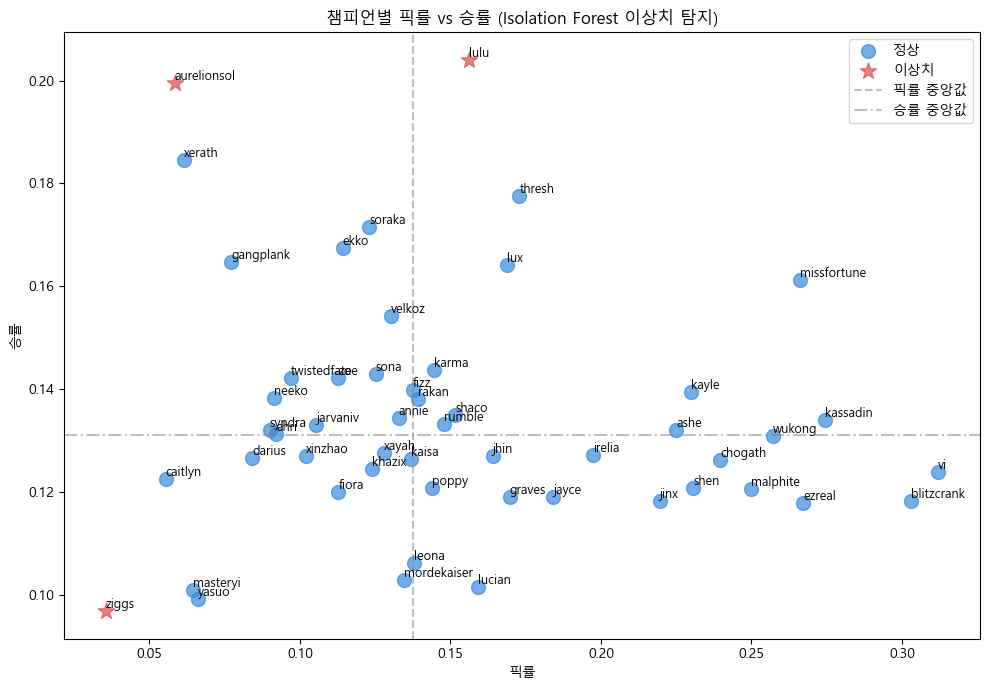

In [11]:
import matplotlib.pyplot as plt
import platform

# 한국어 폰트 설정
if platform.system() == 'Windows':
        plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':
        plt.rcParams['font.family'] = 'AppleGothic'
else:
        plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

fig, ax = plt.subplots(figsize=(10, 7))

# 정상 / 이상치 분리
normal = champ_stats_valid[champ_stats_valid['anomaly'] == 1]
anomaly = champ_stats_valid[champ_stats_valid['anomaly'] == -1]

# 정상 산점도
ax.scatter(normal['pick_rate'], normal['win_rate'],
        c='#378ADD', label='정상', alpha=0.7, s=100)

# 이상치 산점도
ax.scatter(anomaly['pick_rate'], anomaly['win_rate'],
        c='#E24B4A', label='이상치', alpha=0.7, s=150, marker='*')

# 챔피언 이름 표시
for _, row in champ_stats_valid.iterrows():
        ax.annotate(row['name'],
                (row['pick_rate'], row['win_rate']),
                fontsize=9, ha='left', va='bottom')

# 기준선 (중앙값)
ax.axvline(champ_stats_valid['pick_rate'].median(),
        color='gray', linestyle='--', alpha=0.5, label='픽률 중앙값')
ax.axhline(champ_stats_valid['win_rate'].median(),
        color='gray', linestyle='-.', alpha=0.5, label='승률 중앙값')

ax.set_xlabel('픽률')
ax.set_ylabel('승률')
ax.set_title('챔피언별 픽률 vs 승률 (Isolation Forest 이상치 탐지)')
ax.legend()

plt.tight_layout()
plt.show()

#### 이상치 기준 튜닝
- contamination 값을 바꿔가면서 탐색
- 데이터프레임: `champ_stats_valid` 사용 (챔피온)

In [ ]:
# ================================
# 파라미터 튜닝
# ================================
contamination_list = [0.01, 0.03, 0.05, 0.07, 0.09, 0.11]
champ_tuning_results = []

for c in contamination_list:
    model = IsolationForest(contamination=c, random_state=42)
    labels = model.fit_predict(champ_stats_valid[['win_rate', 'pick_rate']])
    outlier_df = champ_stats_valid[labels == -1].copy()
    champ_tuning_results.append({
        'contamination': c,
        'n_outliers': len(outlier_df),
        'outliers': outlier_df['name'].tolist()
    })
    print(f"contamination={c:.2f} → 이상치 {len(outlier_df)}개 | {outlier_df['name'].tolist()}")

champ_tuning_df = pd.DataFrame(champ_tuning_results)

# ================================
# 공통 이상치 분석
# ================================
print("\n===== 공통 이상치 분석 (챔피언) =====")
all_outliers = [name for outliers in champ_tuning_df['outliers'] for name in outliers]
common = pd.Series(all_outliers).value_counts()
common = common[common >= len(contamination_list) // 2]
print(common)

contamination=0.01 → 이상치 1개 | ['ziggs']
contamination=0.03 → 이상치 2개 | ['aurelionsol', 'ziggs']
contamination=0.05 → 이상치 3개 | ['aurelionsol', 'lulu', 'ziggs']
contamination=0.07 → 이상치 4개 | ['aurelionsol', 'lulu', 'missfortune', 'ziggs']
contamination=0.09 → 이상치 5개 | ['aurelionsol', 'lulu', 'missfortune', 'xerath', 'ziggs']
contamination=0.11 → 이상치 6개 | ['aurelionsol', 'lulu', 'missfortune', 'vi', 'xerath', 'ziggs']

===== 공통 이상치 분석 (챔피언) =====
ziggs          6
aurelionsol    5
lulu           4
missfortune    3
Name: count, dtype: int64


---
##### 이상치 탐색 - 평균 등수와 선택률 기준

In [14]:
# 피처 선택
X_champ_1 = champ_stats_valid[['avg_rank', 'pick_rate']]

# Isolation_Forest 모델 정의
iso_forest_champ_1 = IsolationForest(
    contamination=0.05,
    random_state=42
)

# 이상치 탐지
champ_stats_valid['anomaly'] = iso_forest_champ_1.fit_predict(X_champ_1)
champ_stats_valid['anomaly_score'] = iso_forest_champ_1.score_samples(X_champ_1)

# 결과 확인
print(f'전체 챔피언 수: {len(champ_stats_valid)}')
print(f'이상치 개수: {(champ_stats_valid["anomaly"] == -1).sum()}')
print(f'이상치 비율: {(champ_stats_valid["anomaly"] == -1).sum() / len(champ_stats_valid):.2%}')
display(champ_stats_valid[champ_stats_valid['anomaly'] == -1].sort_values('anomaly_score'))

전체 챔피언 수: 52
이상치 개수: 3
이상치 비율: 5.77%


,name,cost,pick_count,avg_rank,win_rate,top4_rate,pick_rate,anomaly,anomaly_score
3,aurelionsol,5,23044,3.539924,0.199488,0.688422,0.058382,-1,-0.665248
50,ziggs,1,14029,4.971274,0.096799,0.410934,0.035542,-1,-0.652853
30,missfortune,5,105056,3.870755,0.161285,0.620717,0.266159,-1,-0.615696


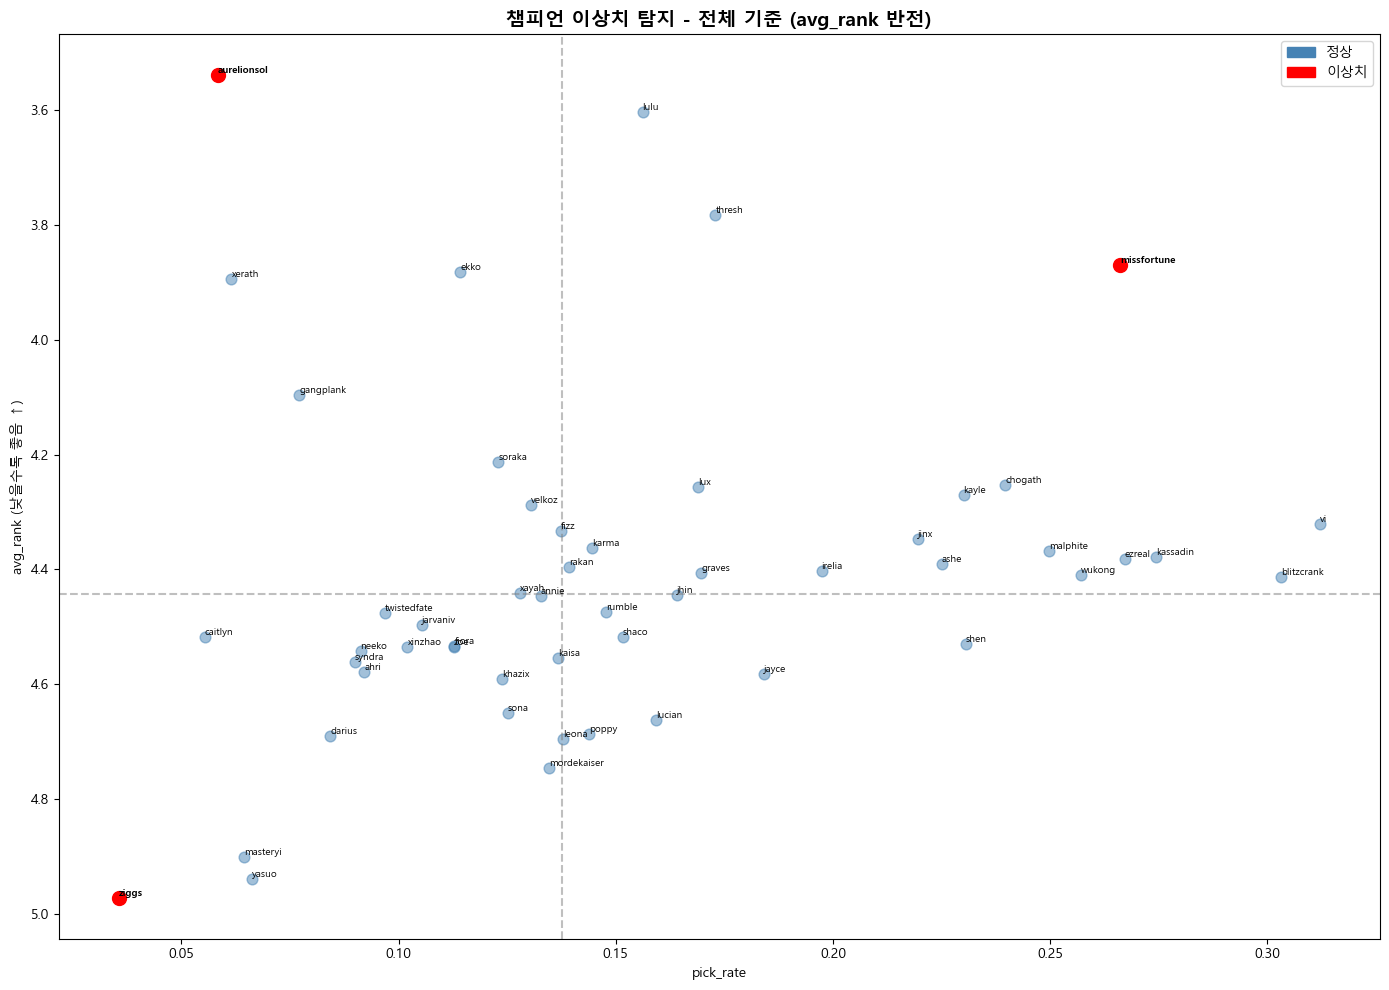

In [16]:
import matplotlib.patches as mpatches

fig, ax = plt.subplots(figsize=(14, 10))

# 정상 / 이상치 분리
normal  = champ_stats_valid[champ_stats_valid['anomaly'] == 1]
outlier = champ_stats_valid[champ_stats_valid['anomaly'] == -1]

# 산점도
ax.scatter(normal['pick_rate'],  normal['avg_rank'],
        color='steelblue', alpha=0.5, s=60, label='정상')
ax.scatter(outlier['pick_rate'], outlier['avg_rank'],
        color='red', s=100, label='이상치')

# 챔피언 이름 표시
for _, row in champ_stats_valid.iterrows():
    ax.annotate(row['name'], (row['pick_rate'], row['avg_rank']),
                fontsize=7, ha='left', va='bottom',
                fontweight='bold' if row['anomaly'] == -1 else 'normal')

# y축 반전
ax.invert_yaxis()

# 기준선 (전체 중앙값)
ax.axvline(x=champ_stats_valid['pick_rate'].median(), color='gray', linestyle='--', alpha=0.5)
ax.axhline(y=champ_stats_valid['avg_rank'].median(),  color='gray', linestyle='--', alpha=0.5)

ax.set_title('챔피언 이상치 탐지 - 전체 기준 (avg_rank 반전)', fontsize=14, fontweight='bold')
ax.set_xlabel('pick_rate')
ax.set_ylabel('avg_rank (낮을수록 좋음 ↑)')

patches = [
    mpatches.Patch(color='steelblue', label='정상'),
    mpatches.Patch(color='red',       label='이상치')
]
ax.legend(handles=patches, fontsize=10)

plt.tight_layout()
plt.show()

In [17]:
# ================================
# 파라미터 튜닝
# ================================
contamination_list_1 = [0.01, 0.03, 0.05, 0.07, 0.09, 0.11]
champ_tuning_results_1 = []

for c in contamination_list_1:
    model_1 = IsolationForest(contamination=c, random_state=42)
    labels_1 = model_1.fit_predict(champ_stats_valid[['avg_rank', 'pick_rate']])
    outlier_df_1 = champ_stats_valid[labels_1 == -1].copy()
    champ_tuning_results_1.append({
        'contamination': c,
        'n_outliers': len(outlier_df_1),
        'outliers': outlier_df_1['name'].tolist()
    })
    print(f"contamination={c:.2f} → 이상치 {len(outlier_df_1)}개 | {outlier_df_1['name'].tolist()}")

champ_tuning_df_1 = pd.DataFrame(champ_tuning_results_1)

# ================================
# 공통 이상치 분석
# ================================
print("\n===== 공통 이상치 분석 (챔피언) =====")
all_outliers_1 = [name for outliers in champ_tuning_df_1['outliers'] for name in outliers]
common_1 = pd.Series(all_outliers_1).value_counts()
common_1 = common_1[common_1 >= len(contamination_list_1) // 2]
print(common_1)

contamination=0.01 → 이상치 1개 | ['aurelionsol']
contamination=0.03 → 이상치 2개 | ['aurelionsol', 'ziggs']
contamination=0.05 → 이상치 3개 | ['aurelionsol', 'missfortune', 'ziggs']
contamination=0.07 → 이상치 4개 | ['aurelionsol', 'lulu', 'missfortune', 'ziggs']
contamination=0.09 → 이상치 5개 | ['aurelionsol', 'lulu', 'missfortune', 'vi', 'ziggs']
contamination=0.11 → 이상치 6개 | ['aurelionsol', 'lulu', 'missfortune', 'thresh', 'vi', 'ziggs']

===== 공통 이상치 분석 (챔피언) =====
aurelionsol    6
ziggs          5
missfortune    4
lulu           3
Name: count, dtype: int64
